# Chapter 41 — Softmax: Turning Scores Into Probabilities

## Learning goals

Chapter 40 introduced classification as producing one raw score, or logit, for every possible class.

Those logits are not probabilities because they may be negative, greater than 1, and need not sum to 1.

This chapter introduces softmax, which converts a finite list of logits into a probability distribution.

By the end of this chapter, you should be able to:

1. Explain why raw logits are not probabilities.
2. Implement direct softmax manually.
3. Verify the range and sum of softmax probabilities.
4. Explain why exponentials are used.
5. Show that softmax preserves score order and argmax.
6. Explain how score gaps affect the distribution.
7. Show that adding one constant to every logit changes no probability.
8. Demonstrate how direct softmax can overflow.
9. Implement stable softmax by subtracting the largest logit.
10. Explain floating-point overflow and underflow.
11. Connect softmax to next-token probabilities.

## The classification example

Use the Chapter 40 input `red fruit` with three classes and three aligned logits:

```text
apple  →  2.5
banana →  0.8
carrot → -1.2
```

Apple has the highest logit, but these three numbers are not yet a probability distribution.

## Terms used in this chapter

- A **logit** is an unrestricted raw class score.
- A **probability** is a value from 0 to 1.
- A **probability distribution** contains probabilities whose sum is 1.
- **Softmax** normalizes exponentiated logits into a probability distribution.
- **Numerical overflow** occurs when a result is too large for the floating-point format.
- **Numerical underflow** occurs when a nonzero result is too close to zero to be represented normally.
- **Stable softmax** subtracts the largest logit before exponentiation.
- **Shift invariance** means adding the same constant to every logit leaves softmax unchanged.

Softmax is shift invariant, but it is not invariant to multiplying logits by a positive scale.

## Set up the raw logits

The class list fixes the meaning of each logit index.

In [1]:
import math

input_text = "red fruit"
possible_classes = ["apple", "banana", "carrot"]
raw_logits = [2.5, 0.8, -1.2]
correct_class = "apple"

if len(possible_classes) != len(raw_logits):
    raise ValueError("There must be exactly one logit per class.")

print("Input:", input_text)
print("class | logit")
print("-" * 20)
for class_name, logit in zip(possible_classes, raw_logits, strict=True):
    print(f"{class_name:>7} | {logit:>5.1f}")

Input: red fruit
class | logit
--------------------
  apple |   2.5
 banana |   0.8
 carrot |  -1.2


## Why logits are not probabilities

A probability distribution contains no negative values, contains no values above 1, and sums to 1 within floating-point tolerance.

In [2]:
all_logits_in_probability_range = all(0.0 <= logit <= 1.0 for logit in raw_logits)
raw_logit_sum = sum(raw_logits)
logits_sum_to_one = math.isclose(raw_logit_sum, 1.0, abs_tol=1e-12)

print("Raw logits:", raw_logits)
print("All between 0 and 1?", all_logits_in_probability_range)
print("Sum:", raw_logit_sum)
print("Sum is 1?", logits_sum_to_one)

assert not all_logits_in_probability_range
assert not logits_sum_to_one

Raw logits: [2.5, 0.8, -1.2]
All between 0 and 1? False
Sum: 2.1
Sum is 1? False


## The softmax formula

For logits `z₁, z₂, ..., zₙ`, softmax assigns class `i` the probability:

```text
exp(zᵢ)
──────────────────
Σⱼ exp(zⱼ)
```

Exponentiation makes every finite mathematical numerator positive, and division by the shared total makes all outputs sum to 1.

## Implement direct softmax

The direct implementation mirrors the formula and is useful for understanding the calculation.

Finite-input validation catches undefined inputs such as infinity and NaN, but it does not prevent large finite logits from overflowing during exponentiation.

In [3]:
def validate_logits(logits: list[float]) -> None:
    if not logits:
        raise ValueError("logits must not be empty.")

    if not all(math.isfinite(logit) for logit in logits):
        raise ValueError("Every logit must be finite.")


def direct_softmax(logits: list[float]) -> list[float]:
    validate_logits(logits)
    exponentials = [math.exp(logit) for logit in logits]
    exponential_total = sum(exponentials)
    return [value / exponential_total for value in exponentials]


direct_probabilities = direct_softmax(raw_logits)

print("Raw logits:", raw_logits)
print("Exponentials:", [math.exp(logit) for logit in raw_logits])
print("Probabilities:", direct_probabilities)
print("Probability sum:", sum(direct_probabilities))

Raw logits: [2.5, 0.8, -1.2]
Exponentials: [12.182493960703473, 2.225540928492468, 0.30119421191220214]
Probabilities: [0.8282211037005118, 0.1513023499188549, 0.02047654638063331]
Probability sum: 1.0


## Inspect each class

The largest logit receives the largest probability, and the smallest logit receives the smallest probability.

In [4]:
print("class | raw logit | softmax probability")
print("-" * 46)
for class_name, logit, probability in zip(
    possible_classes,
    raw_logits,
    direct_probabilities,
    strict=True,
):
    print(f"{class_name:>7} | {logit:>9.4f} | {probability:>19.6f}")

class | raw logit | softmax probability
----------------------------------------------
  apple |    2.5000 |            0.828221
 banana |    0.8000 |            0.151302
 carrot |   -1.2000 |            0.020477


## Validate the probability distribution

Floating-point sums are approximate, so numerical code checks closeness to 1 rather than exact equality.

In [5]:
def assert_valid_probability_distribution(
    probabilities: list[float],
    tolerance: float = 1e-12,
) -> None:
    if not probabilities:
        raise ValueError("probabilities must not be empty.")

    if not all(math.isfinite(probability) for probability in probabilities):
        raise ValueError("Every probability must be finite.")

    if not all(0.0 <= probability <= 1.0 for probability in probabilities):
        raise ValueError("Every probability must be between 0 and 1.")

    if not math.isclose(sum(probabilities), 1.0, abs_tol=tolerance):
        raise ValueError("Probabilities must sum to 1.")


assert_valid_probability_distribution(direct_probabilities)
print("The direct softmax output is a valid probability distribution.")

The direct softmax output is a valid probability distribution.


## Why use exponentials?

The exponential of every finite real number is mathematically positive.

More importantly, exponentials turn a logit difference into a probability ratio:

```text
pᵢ / pⱼ = exp(zᵢ - zⱼ)
```

A one-unit logit advantage therefore corresponds to an odds ratio of `e¹`, regardless of the shared denominator.

In [6]:
exponential_examples = [-3.0, -1.0, 0.0, 1.0, 3.0]

print("number | exp(number)")
print("-" * 23)
for example_number in exponential_examples:
    print(f"{example_number:>6.1f} | {math.exp(example_number):>11.6f}")

apple_to_banana_probability_ratio = direct_probabilities[0] / direct_probabilities[1]
apple_to_banana_expected_ratio = math.exp(raw_logits[0] - raw_logits[1])

print()
print("Apple/Banana probability ratio:", apple_to_banana_probability_ratio)
print("exp(Apple logit - Banana logit):", apple_to_banana_expected_ratio)

assert math.isclose(
    apple_to_banana_probability_ratio,
    apple_to_banana_expected_ratio,
    rel_tol=1e-12,
)

number | exp(number)
-----------------------
  -3.0 |    0.049787
  -1.0 |    0.367879
   0.0 |    1.000000
   1.0 |    2.718282
   3.0 |   20.085537

Apple/Banana probability ratio: 5.473947391727199
exp(Apple logit - Banana logit): 5.4739473917272


## Softmax preserves order and argmax

Exponentiation is strictly increasing, and division uses the same positive denominator for every class.

Therefore a higher finite logit receives a higher mathematical softmax probability.

In [7]:
def index_of_largest_value(values: list[float]) -> int:
    if not values:
        raise ValueError("values must not be empty.")

    largest_index = 0

    for value_index in range(1, len(values)):
        if values[value_index] > values[largest_index]:
            largest_index = value_index

    return largest_index


highest_logit_index = index_of_largest_value(raw_logits)
highest_probability_index = index_of_largest_value(direct_probabilities)

print("Winner from logits:", possible_classes[highest_logit_index])
print("Winner from probabilities:", possible_classes[highest_probability_index])

assert highest_logit_index == highest_probability_index

Winner from logits: apple
Winner from probabilities: apple


## Compare logits and probabilities visually

The two quantities use different scales, so place them on separate axes rather than implying that their bar heights are directly comparable.

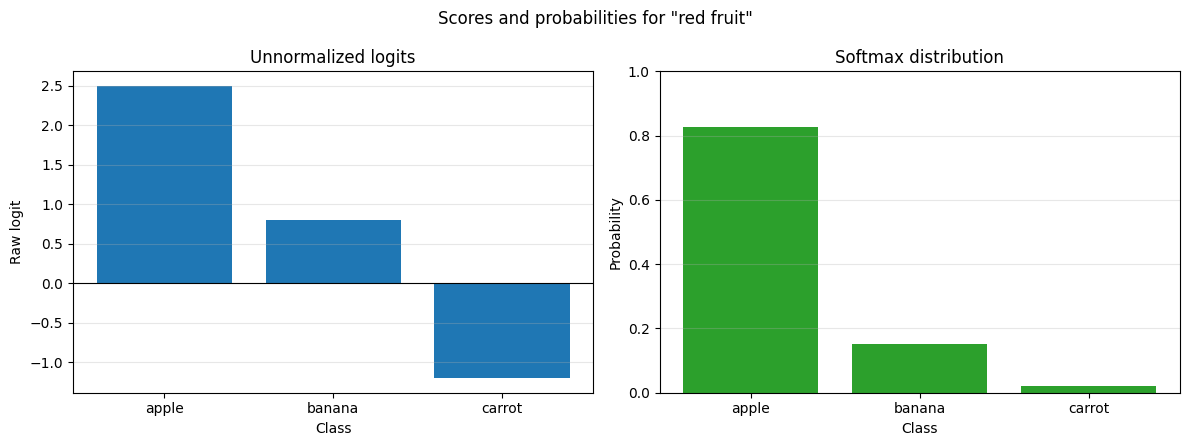

In [8]:
import matplotlib.pyplot as plt

comparison_figure, comparison_axes = plt.subplots(1, 2, figsize=(12, 4.5))
comparison_axes[0].bar(possible_classes, raw_logits, color="tab:blue")
comparison_axes[0].axhline(0.0, color="black", linewidth=0.8)
comparison_axes[0].set_xlabel("Class")
comparison_axes[0].set_ylabel("Raw logit")
comparison_axes[0].set_title("Unnormalized logits")
comparison_axes[0].grid(True, axis="y", alpha=0.3)

comparison_axes[1].bar(
    possible_classes,
    direct_probabilities,
    color="tab:green",
)
comparison_axes[1].set_xlabel("Class")
comparison_axes[1].set_ylabel("Probability")
comparison_axes[1].set_ylim(0.0, 1.0)
comparison_axes[1].set_title("Softmax distribution")
comparison_axes[1].grid(True, axis="y", alpha=0.3)

comparison_figure.suptitle('Scores and probabilities for "red fruit"')
comparison_figure.tight_layout()
plt.show()

## Softmax depends on score gaps

Close logits produce a more spread-out distribution, while a large leading gap produces a more concentrated distribution.

This is why multiplying all logits by a positive constant may preserve argmax but still change probabilities substantially.

In [9]:
small_gap_logits = [1.0, 0.9, 0.8]
large_gap_logits = [10.0, 0.0, -10.0]
small_gap_probabilities = direct_softmax(small_gap_logits)
large_gap_probabilities = direct_softmax(large_gap_logits)

print("Small-gap probabilities:", small_gap_probabilities)
print("Large-gap probabilities:", large_gap_probabilities)
print("Largest small-gap probability:", max(small_gap_probabilities))
print("Largest large-gap probability:", max(large_gap_probabilities))

assert max(large_gap_probabilities) > max(small_gap_probabilities)

Small-gap probabilities: [0.36716540111092544, 0.3322249935333473, 0.3006096053557273]
Large-gap probabilities: [0.999954600070331, 4.5397868608866656e-05, 2.061060046209062e-09]
Largest small-gap probability: 0.36716540111092544
Largest large-gap probability: 0.999954600070331


## Changing one logit affects every probability

All classes share one normalization total, so increasing banana's logit raises its probability and redistributes probability mass away from competitors.

In [10]:
modified_logits = [2.5, 3.0, -1.2]
modified_probabilities = direct_softmax(modified_logits)

print("class | original probability | modified probability")
print("-" * 55)
for class_name, original_probability, modified_probability in zip(
    possible_classes,
    direct_probabilities,
    modified_probabilities,
    strict=True,
):
    print(
        f"{class_name:>7} | {original_probability:>20.6f} | "
        f"{modified_probability:>20.6f}"
    )

assert index_of_largest_value(modified_probabilities) == 1

class | original probability | modified probability
-------------------------------------------------------
  apple |             0.828221 |             0.374049
 banana |             0.151302 |             0.616703
 carrot |             0.020477 |             0.009248


## Adding one constant changes nothing

For any constant `c`, the exponential identity `exp(z + c) = exp(z) × exp(c)` gives every numerator and the denominator the same factor.

That factor cancels, so softmax is shift invariant.

In [11]:
shifted_logits = [logit + 100.0 for logit in raw_logits]
shifted_probabilities = direct_softmax(shifted_logits)

print("Original probabilities:", direct_probabilities)
print("Shifted probabilities:", shifted_probabilities)
print("Absolute differences:")

for original_probability, shifted_probability in zip(
    direct_probabilities,
    shifted_probabilities,
    strict=True,
):
    difference = abs(original_probability - shifted_probability)
    print(f"  {difference:.3e}")
    assert math.isclose(
        original_probability,
        shifted_probability,
        rel_tol=1e-12,
        abs_tol=1e-12,
    )

Original probabilities: [0.8282211037005118, 0.1513023499188549, 0.02047654638063331]
Shifted probabilities: [0.8282211037005123, 0.15130234991885455, 0.020476546380633263]
Absolute differences:
  4.441e-16
  3.608e-16
  4.857e-17


## Direct softmax can overflow

`math.exp(1000)` is too large for an ordinary Python floating-point number.

Catch the expected exception so the notebook can demonstrate the failure without stopping execution.

In [12]:
large_logits = [1000.0, 1001.0, 1002.0]

try:
    direct_softmax(large_logits)
except OverflowError as overflow_error:
    print("Direct softmax failed as expected:")
    print(type(overflow_error).__name__, "-", overflow_error)
else:
    raise AssertionError("The direct example was expected to overflow.")

Direct softmax failed as expected:
OverflowError - math range error


## Stable softmax

Subtract the largest logit before exponentiating.

The largest shifted value becomes zero, so the largest exponential is `exp(0) = 1` rather than an enormous number.

Shift invariance guarantees that this produces the same mathematical probabilities.

In [13]:
def stable_softmax(logits: list[float]) -> list[float]:
    validate_logits(logits)
    largest_logit = max(logits)
    shifted_logits = [logit - largest_logit for logit in logits]
    shifted_exponentials = [math.exp(logit) for logit in shifted_logits]
    exponential_total = sum(shifted_exponentials)
    probabilities = [value / exponential_total for value in shifted_exponentials]
    assert_valid_probability_distribution(probabilities)
    return probabilities


stable_probabilities = stable_softmax(raw_logits)

print("Direct probabilities:", direct_probabilities)
print("Stable probabilities:", stable_probabilities)

for direct_probability, stable_probability in zip(
    direct_probabilities,
    stable_probabilities,
    strict=True,
):
    assert math.isclose(
        direct_probability,
        stable_probability,
        rel_tol=1e-12,
        abs_tol=1e-12,
    )

Direct probabilities: [0.8282211037005118, 0.1513023499188549, 0.02047654638063331]
Stable probabilities: [0.8282211037005118, 0.15130234991885488, 0.020476546380633308]


## Stable softmax handles the large logits

The dangerous logits `[1000, 1001, 1002]` shift to `[-2, -1, 0]` before exponentiation.

In [14]:
largest_large_logit = max(large_logits)
shifted_large_logits = [logit - largest_large_logit for logit in large_logits]
large_logit_probabilities = stable_softmax(large_logits)

print("Original logits:", large_logits)
print("Shifted logits:", shifted_large_logits)
print("Shifted exponentials:", [math.exp(logit) for logit in shifted_large_logits])
print("Stable probabilities:", large_logit_probabilities)
print("Probability sum:", sum(large_logit_probabilities))

assert max(shifted_large_logits) == 0.0
assert_valid_probability_distribution(large_logit_probabilities)

Original logits: [1000.0, 1001.0, 1002.0]
Shifted logits: [-2.0, -1.0, 0.0]
Shifted exponentials: [0.1353352832366127, 0.36787944117144233, 1.0]
Stable probabilities: [0.09003057317038046, 0.24472847105479764, 0.6652409557748218]
Probability sum: 0.9999999999999999


## Stable does not mean infinite-range arithmetic

For finite real numbers, mathematical softmax probabilities are strictly positive.

In floating-point arithmetic, an extremely negative shifted logit may underflow so its exponential and reported probability round to zero.

This is safer than positive overflow, but it is still a finite-precision effect worth recognizing.

In [15]:
extreme_gap_logits = [0.0, -1000.0]
extreme_gap_probabilities = stable_softmax(extreme_gap_logits)

print("Extreme-gap logits:", extreme_gap_logits)
print("Floating-point probabilities:", extreme_gap_probabilities)
print("math.exp(-1000):", math.exp(-1000.0))

assert extreme_gap_probabilities == [1.0, 0.0]

Extreme-gap logits: [0.0, -1000.0]
Floating-point probabilities: [1.0, 0.0]
math.exp(-1000): 0.0


## Reject non-finite logits

Subtracting the maximum cannot rescue inputs such as positive infinity or NaN because expressions like `infinity - infinity` are undefined.

In [16]:
try:
    stable_softmax([0.0, math.inf])
except ValueError as non_finite_error:
    print("Rejected non-finite logits:", non_finite_error)
else:
    raise AssertionError("Non-finite logits should be rejected.")

Rejected non-finite logits: Every logit must be finite.


## Softmax for next-token prediction

At one language-model position, vocabulary tokens are the classes and the model emits one logit per token.

In [17]:
context_text = "the cat sat on the"
vocabulary_tokens = ["mat", "rug", "dog", "apple", "."]
next_token_logits = [3.2, 2.1, -0.5, -2.0, 0.3]
next_token_probabilities = stable_softmax(next_token_logits)
predicted_next_token_id = index_of_largest_value(next_token_probabilities)

print("Context:", context_text)
print("token | logit | probability")
print("-" * 34)
for token, logit, probability in zip(
    vocabulary_tokens,
    next_token_logits,
    next_token_probabilities,
    strict=True,
):
    print(f"{token:>6} | {logit:>5.1f} | {probability:>11.6f}")

print("Predicted next token:", vocabulary_tokens[predicted_next_token_id])
assert math.isclose(sum(next_token_probabilities), 1.0, abs_tol=1e-12)

Context: the cat sat on the
token | logit | probability
----------------------------------
   mat |   3.2 |    0.705152
   rug |   2.1 |    0.234725
   dog |  -0.5 |    0.017434
 apple |  -2.0 |    0.003890
     . |   0.3 |    0.038800
Predicted next token: mat


## Plot next-token probabilities

The distribution shows both the most likely token and the probability mass assigned to alternatives.

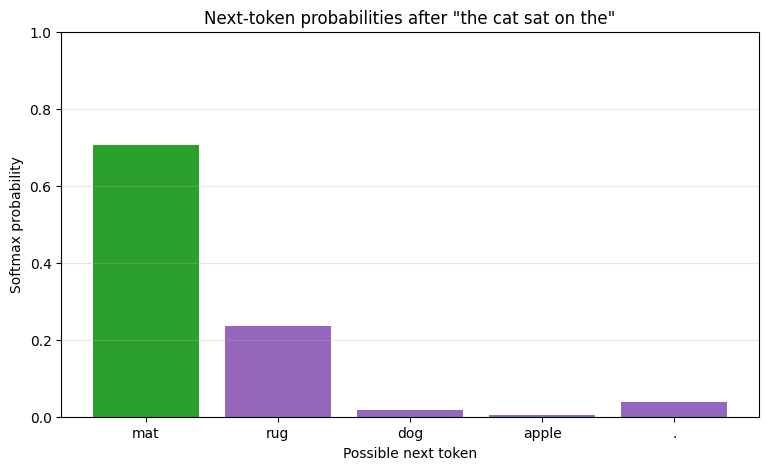

In [18]:
next_token_colors = [
    "tab:green" if token_id == predicted_next_token_id else "tab:purple"
    for token_id in range(len(vocabulary_tokens))
]

plt.figure(figsize=(9, 5))
plt.bar(
    vocabulary_tokens,
    next_token_probabilities,
    color=next_token_colors,
)
plt.xlabel("Possible next token")
plt.ylabel("Softmax probability")
plt.ylim(0.0, 1.0)
plt.title(f'Next-token probabilities after "{context_text}"')
plt.grid(True, axis="y", alpha=0.3)
plt.show()

## The target-class probability

Classification training cares about the probability assigned to the dataset's correct class, not only the argmax decision.

Cross-entropy will turn that target-class probability into a loss in the next chapter.

In [19]:
correct_class_id = possible_classes.index(correct_class)
correct_class_probability = stable_probabilities[correct_class_id]

print("Correct class:", correct_class)
print("Correct class ID:", correct_class_id)
print("Probability assigned to correct class:", correct_class_probability)

assert correct_class_probability == max(stable_probabilities)

Correct class: apple
Correct class ID: 0
Probability assigned to correct class: 0.8282211037005118


## A vocabulary-sized distribution

A vocabulary of 50 tokens produces 50 logits and, after softmax, 50 aligned probabilities at one position.

In [20]:
fake_vocabulary = [f"token_{token_id}" for token_id in range(50)]
fake_logits = [-2.0 + 0.1 * token_id for token_id in range(50)]
fake_probabilities = stable_softmax(fake_logits)

print("Vocabulary size:", len(fake_vocabulary))
print("Logit count:", len(fake_logits))
print("Probability count:", len(fake_probabilities))
print("Probability sum:", sum(fake_probabilities))

assert len(fake_vocabulary) == len(fake_logits) == len(fake_probabilities) == 50

Vocabulary size: 50
Logit count: 50
Probability count: 50
Probability sum: 1.0


## Inspect top probabilities

Large vocabularies are often summarized by sorting token-probability pairs and displaying only the largest few.

In [21]:
def top_items(
    labels: list[str],
    values: list[float],
    top_count: int,
) -> list[tuple[str, float]]:
    if len(labels) != len(values):
        raise ValueError("labels and values must have the same length.")

    if not 1 <= top_count <= len(labels):
        raise ValueError("top_count must be between 1 and the number of labels.")

    paired_items = list(zip(labels, values, strict=True))
    return sorted(paired_items, key=lambda item: item[1], reverse=True)[:top_count]


top_token_probabilities = top_items(fake_vocabulary, fake_probabilities, 5)

print("Top 5 token probabilities:")
for token, probability in top_token_probabilities:
    print(f"{token:>8} → {probability:.6f}")

Top 5 token probabilities:
token_49 → 0.095808
token_48 → 0.086691
token_47 → 0.078441
token_46 → 0.070976
token_45 → 0.064222


## Probability is not guaranteed correctness

A high softmax probability means the model assigned one class a substantially larger logit than its competitors.

It does not guarantee that the prediction is correct or that the stated probability matches real-world frequency.

Probability calibration depends on the model, data, and training process.

## Softmax does not train the model

Softmax transforms logits into probabilities but does not update parameters.

A loss function must evaluate those outputs and backpropagation must provide parameter gradients.

In practical libraries, cross-entropy is often computed directly from logits with a stable log-sum-exp calculation instead of materializing probabilities and then taking a logarithm.

## A clean stable-softmax pipeline

This compact example validates logits, applies stable softmax, checks the distribution, finds the prediction, and plots both representations.

class | logit | probability
----------------------------------
  apple |   2.5 |    0.828221
 banana |   0.8 |    0.151302
 carrot |  -1.2 |    0.020477
Predicted class: apple


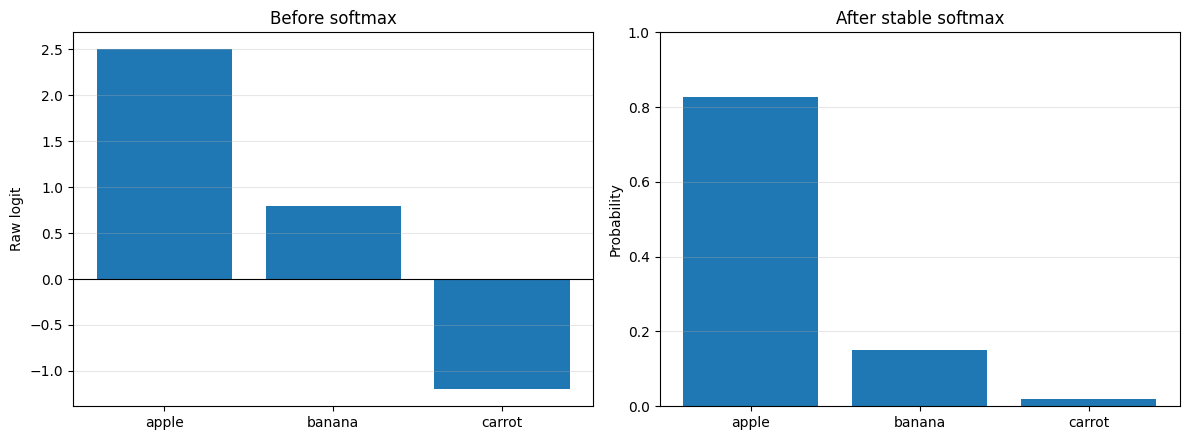

In [22]:
pipeline_classes = ["apple", "banana", "carrot"]
pipeline_logits = [2.5, 0.8, -1.2]
pipeline_probabilities = stable_softmax(pipeline_logits)
pipeline_prediction_id = index_of_largest_value(pipeline_probabilities)

assert_valid_probability_distribution(pipeline_probabilities)

print("class | logit | probability")
print("-" * 34)
for pipeline_class, pipeline_logit, pipeline_probability in zip(
    pipeline_classes,
    pipeline_logits,
    pipeline_probabilities,
    strict=True,
):
    print(
        f"{pipeline_class:>7} | {pipeline_logit:>5.1f} | {pipeline_probability:>11.6f}"
    )

print("Predicted class:", pipeline_classes[pipeline_prediction_id])

pipeline_figure, pipeline_axes = plt.subplots(1, 2, figsize=(12, 4.5))
pipeline_axes[0].bar(pipeline_classes, pipeline_logits)
pipeline_axes[0].axhline(0.0, color="black", linewidth=0.8)
pipeline_axes[0].set_ylabel("Raw logit")
pipeline_axes[0].set_title("Before softmax")
pipeline_axes[0].grid(True, axis="y", alpha=0.3)

pipeline_axes[1].bar(pipeline_classes, pipeline_probabilities)
pipeline_axes[1].set_ylabel("Probability")
pipeline_axes[1].set_ylim(0.0, 1.0)
pipeline_axes[1].set_title("After stable softmax")
pipeline_axes[1].grid(True, axis="y", alpha=0.3)

pipeline_figure.tight_layout()
plt.show()

## What not to do

- Do not treat logits as probabilities.
- Do not use direct softmax for large logits in serious numerical code.
- Do not omit finite-input validation when writing defensive teaching code.
- Do not assume multiplying every logit by a positive constant preserves probabilities.
- Do not mistake floating-point underflow to zero for mathematical softmax reaching exactly zero.
- Do not interpret a high model probability as a guarantee of correctness.
- Do not expect softmax alone to train model parameters.

## Gotchas

### Softmax compares all classes together

Changing one logit changes the shared denominator and therefore can change every probability.

### Shift invariance enables stability

Subtracting the maximum changes no mathematical probability.

### Scale changes concentration

Larger logit gaps generally produce a more concentrated distribution.

### Direct exponentiation can overflow

Large positive finite logits may make `math.exp` raise `OverflowError`.

### Stable softmax may still underflow tiny terms

An extremely unlikely class can round to probability zero in finite-precision arithmetic.

## Takeaways

Softmax converts finite raw logits into a probability distribution:

```text
softmax(zᵢ) = exp(zᵢ) / Σⱼ exp(zⱼ)
```

It preserves score order, assigns more probability to higher logits, and normalizes the outputs to sum to 1.

The recommended manual implementation subtracts the maximum first:

```python
largest_logit = max(logits)
shifted_logits = [logit - largest_logit for logit in logits]
exponentials = [math.exp(logit) for logit in shifted_logits]
probabilities = [value / sum(exponentials) for value in exponentials]
```

For language modeling, vocabulary-sized logits become vocabulary-sized next-token probabilities at every position.

## What comes next

The next chapter introduces cross-entropy loss.

Cross-entropy turns the probability assigned to the correct class into a scalar training objective, with lower loss for higher target probability and higher loss for lower target probability.